# **Detection Benchmark**
**db_resnet50 vs db_mobilenet_v3_large**

## What we're comparing
Both models use **DBNet** (Differentiable Binarization) as their detection head.
The only difference is the backbone feeding features into it:

| | db_resnet50 | db_mobilenet_v3_large |
|---|---|---|
| **Backbone** | ResNet50 (~25M params) | MobileNetV3-Large (~5M params) |
| **Detection head** | DBNet (identical) | DBNet (identical) |
| **Designed for** | Max accuracy, GPU server | Edge / latency-constrained |
| **Expected speed** | Slower | ~3-4x faster |
| **Expected accuracy** | Higher, especially small text | Good on clear text |

Any difference in results is **purely attributable to backbone feature quality** clean, isolated experiment.

## **Decision rule**
Pick the model with the best F1 whose **P95 latency stays under the 2s budget**.
If both fit, prefer resnet50 only if F1 gain is meaningful (>3 points).
Otherwise mobilenet wins - save the latency headroom for the recognition stage.

**Input:** `data/processed/benchmark_sample/` (from `extract_benchmark_sample.py`)  
**Output:** `outputs/results/02a_detection_summary.csv`, `02a_decision.json`

## 1. Mount Drive & Install

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip("python-doctr[torch]")
pip("pandas")
pip("seaborn")

print("Done installing dependencies.")

Done installing dependencies.


## 2. Imports & Paths

In [4]:
import json, random, time
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from doctr.models import detection_predictor

random.seed(42)
np.random.seed(42)

# ── Paths ──
DRIVE_ROOT  = Path("/content/drive/MyDrive")
SAMPLE_DIR  = DRIVE_ROOT / "benchmark_sample"
IMG_DIR     = SAMPLE_DIR / "images"
RESULTS_DIR = DRIVE_ROOT / "outputs/results"
FIGURES_DIR = DRIVE_ROOT / "outputs/figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Benchmark config ──
IOU_THRESHOLD  = 0.5
LATENCY_BUDGET = 2.0
F1_MIN_GAIN    = 0.03  # resnet50 must beat mobilenet by this to justify its latency cost

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

assert SAMPLE_DIR.exists(), f"benchmark_sample/ not found: {SAMPLE_DIR}"
assert IMG_DIR.exists(),    "images/ subfolder missing — re-run extract_benchmark_sample.py"
print("Paths OK ✓")

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
Paths OK ✓


## 3. Load Detection Sample

In [5]:
with open(SAMPLE_DIR / "detection_sample.json") as f:
    detection_sample = json.load(f)

with open(SAMPLE_DIR / "sample_stats.json") as f:
    stats = json.load(f)

missing = [s for s in detection_sample if not (IMG_DIR / s["file_name"]).exists()]
print(f"Images         : {len(detection_sample)}")
print(f"Total GT boxes : {stats['detection']['total_gt_boxes']}")
print(f"Mean GT/image  : {stats['detection']['mean_gt_boxes_per_image']:.1f}")
print(f"Missing files  : {len(missing)}  {'✓' if not missing else '← fix before continuing'}")

Images         : 200
Total GT boxes : 960
Mean GT/image  : 4.8
Missing files  : 0  ✓


## 4. Scoring Utilities

In [ ]:
def xywh_to_xyxy(b):
    x, y, w, h = b
    return [x, y, x+w, y+h]

def compute_iou(a, b):
    ax1,ay1,ax2,ay2 = a
    bx1,by1,bx2,by2 = b
    inter = max(0, min(ax2,bx2)-max(ax1,bx1)) * max(0, min(ay2,by2)-max(ay1,by1))
    if not inter: return 0.0
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter/union if union else 0.0

def match_boxes(preds, gts, thresh=0.5):
    """
    Greedy IoU matching → (tp, fp, fn, mean_iou_of_matches).
    Each GT box matched at most once.
    """
    if not preds: return 0, 0, len(gts), 0.0
    if not gts:   return 0, len(preds), 0, 0.0
    preds_xy = [xywh_to_xyxy(b) for b in preds]
    gts_xy   = [xywh_to_xyxy(b) for b in gts]
    matched, tp, fp, ious = set(), 0, 0, []
    for p in preds_xy:
        best, bi = 0.0, -1
        for i, g in enumerate(gts_xy):
            if i in matched: continue
            s = compute_iou(p, g)
            if s > best: best, bi = s, i
        if best >= thresh: tp+=1; matched.add(bi); ious.append(best)
        else: fp+=1
    return tp, fp, len(gts)-len(matched), float(np.mean(ious)) if ious else 0.0

def aggregate(results):
    tp   = sum(r["tp"] for r in results)
    fp   = sum(r["fp"] for r in results)
    fn   = sum(r["fn"] for r in results)
    pre  = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*pre*rec/(pre+rec) if (pre+rec) else 0.0
    lats = [r["latency"] for r in results]
    ious = [r["mean_iou"] for r in results if r["mean_iou"] > 0]
    return {
        "precision":      pre,
        "recall":         rec,
        "f1":             f1,
        "mean_iou":       float(np.mean(ious)) if ious else 0.0,
        "mean_latency_s": float(np.mean(lats)),
        "p95_latency_s":  float(np.percentile(lats, 95)),
        "total_tp": tp, "total_fp": fp, "total_fn": fn
    }

print("Scoring utilities ready ")

Scoring utilities ready 


## 5. Shared Inference Function

In [ ]:
def run_doctr_det(model, img_path, img_w, img_h):
    img_np = np.array(Image.open(img_path).convert("RGB"))

    t0 = time.perf_counter()
    with torch.no_grad():
        result = model([img_np])
    latency = time.perf_counter() - t0

    pred_boxes = []
    try:
        for row in result[0]["words"]:
            # row = [x_min, y_min, x_max, y_max, confidence] in relative coords [0,1]
            x1 = row[0] * img_w
            y1 = row[1] * img_h
            x2 = row[2] * img_w
            y2 = row[3] * img_h
            w, h = x2 - x1, y2 - y1
            if w > 0 and h > 0:
                pred_boxes.append([float(x1), float(y1), float(w), float(h)])
    except (KeyError, IndexError, TypeError):
        pass

    return pred_boxes, latency

def run_benchmark(model, model_name):
    """Full benchmark loop. Returns per-image results and aggregate metrics."""
    print(f"Running {model_name} on {len(detection_sample)} images...")
    results = []
    for i, s in enumerate(detection_sample):
        img_path = IMG_DIR / s["file_name"]
        preds, lat = run_doctr_det(model, img_path, s["width"], s["height"])
        tp, fp, fn, iou = match_boxes(preds, s["gt_boxes"], IOU_THRESHOLD)
        results.append({
            "image_id": s["image_id"],
            "tp": tp, "fp": fp, "fn": fn,
            "mean_iou": iou, "latency": lat,
            "n_pred": len(preds), "n_gt": s["n_gt_boxes"]
        })
        if (i+1) % 50 == 0: print(f"  {i+1}/{len(detection_sample)}")
    m = aggregate(results)
    print(f"\n{model_name}:")
    for k, v in m.items():
        print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")
    return results, m

print("Inference utilities ready ")

Inference utilities ready 


## 6. Load Models

In [11]:
print("Loading db_resnet50...")
model_r50 = detection_predictor(
    "db_resnet50",
    pretrained=True,
    assume_straight_pages=True
).to(DEVICE)
model_r50.eval()
print("db_resnet50 ready ✓")

print("Loading db_mobilenet_v3_large...")
model_mob = detection_predictor(
    "db_mobilenet_v3_large",
    pretrained=True,
    assume_straight_pages=True
).to(DEVICE)
model_mob.eval()
print("db_mobilenet_v3_large ready ✓")

Loading db_resnet50...
db_resnet50 ready ✓
Loading db_mobilenet_v3_large...
db_mobilenet_v3_large ready ✓


## **7. db_resnet50**

In [12]:
r50_results, r50_m = run_benchmark(model_r50, "db_resnet50")

Running db_resnet50 on 200 images...
  50/200
  100/200
  150/200
  200/200

db_resnet50:
  precision             : 0.3535
  recall                : 0.5062
  f1                    : 0.4163
  mean_iou              : 0.7286
  mean_latency_s        : 0.1380
  p95_latency_s         : 0.1686
  total_tp              : 486
  total_fp              : 889
  total_fn              : 474


In [13]:
import numpy as np
from PIL import Image

# inspect raw output on one image
s = detection_sample[0]
img_np = np.array(Image.open(IMG_DIR / s["file_name"]).convert("RGB"))

with torch.no_grad():
    raw = model_r50([img_np])

print("Top-level keys:", list(raw[0].keys()))
print("Full output:")
import json
# print first few entries
for k, v in raw[0].items():
    print(f"  {k}: type={type(v)}, value={v[:3] if hasattr(v, '__len__') else v}")

Top-level keys: ['words']
Full output:
  words: type=<class 'numpy.ndarray'>, value=[[0.05957031 0.65151515 0.08203125 0.66899767 0.25672844]
 [0.81640625 0.58304196 0.89453125 0.64568765 0.33534515]
 [0.80957031 0.53350816 0.87792969 0.59615385 0.45626473]]


## **8. Run db_mobilenet_v3_large**

In [14]:
mob_results, mob_m = run_benchmark(model_mob, "db_mobilenet_v3_large")

Running db_mobilenet_v3_large on 200 images...
  50/200
  100/200
  150/200
  200/200

db_mobilenet_v3_large:
  precision             : 0.2183
  recall                : 0.4813
  f1                    : 0.3004
  mean_iou              : 0.7010
  mean_latency_s        : 0.1074
  p95_latency_s         : 0.1390
  total_tp              : 462
  total_fp              : 1654
  total_fn              : 498


## 9. Compare & Plot

In [15]:
# ── Summary table ──
comparison = pd.DataFrame({
    "Metric":              ["Precision","Recall","F1","Mean IoU",
                            "Mean Latency (s)","P95 Latency (s)",
                            "TP","FP","FN"],
    "db_resnet50":         [r50_m["precision"], r50_m["recall"],
                            r50_m["f1"],        r50_m["mean_iou"],
                            r50_m["mean_latency_s"], r50_m["p95_latency_s"],
                            r50_m["total_tp"],  r50_m["total_fp"], r50_m["total_fn"]],
    "db_mobilenet_v3":     [mob_m["precision"], mob_m["recall"],
                            mob_m["f1"],        mob_m["mean_iou"],
                            mob_m["mean_latency_s"], mob_m["p95_latency_s"],
                            mob_m["total_tp"],  mob_m["total_fp"], mob_m["total_fn"]],
})
print(comparison.to_string(index=False))
comparison.to_csv(RESULTS_DIR / "02a_detection_summary.csv", index=False)
pd.DataFrame(r50_results).to_csv(RESULTS_DIR / "02a_r50_per_image.csv",  index=False)
pd.DataFrame(mob_results).to_csv(RESULTS_DIR / "02a_mob_per_image.csv",  index=False)
print("\nCSVs saved ✓")

          Metric  db_resnet50  db_mobilenet_v3
       Precision     0.353455         0.218336
          Recall     0.506250         0.481250
              F1     0.416274         0.300390
        Mean IoU     0.728628         0.701041
Mean Latency (s)     0.137981         0.107359
 P95 Latency (s)     0.168558         0.139034
              TP   486.000000       462.000000
              FP   889.000000      1654.000000
              FN   474.000000       498.000000

CSVs saved ✓


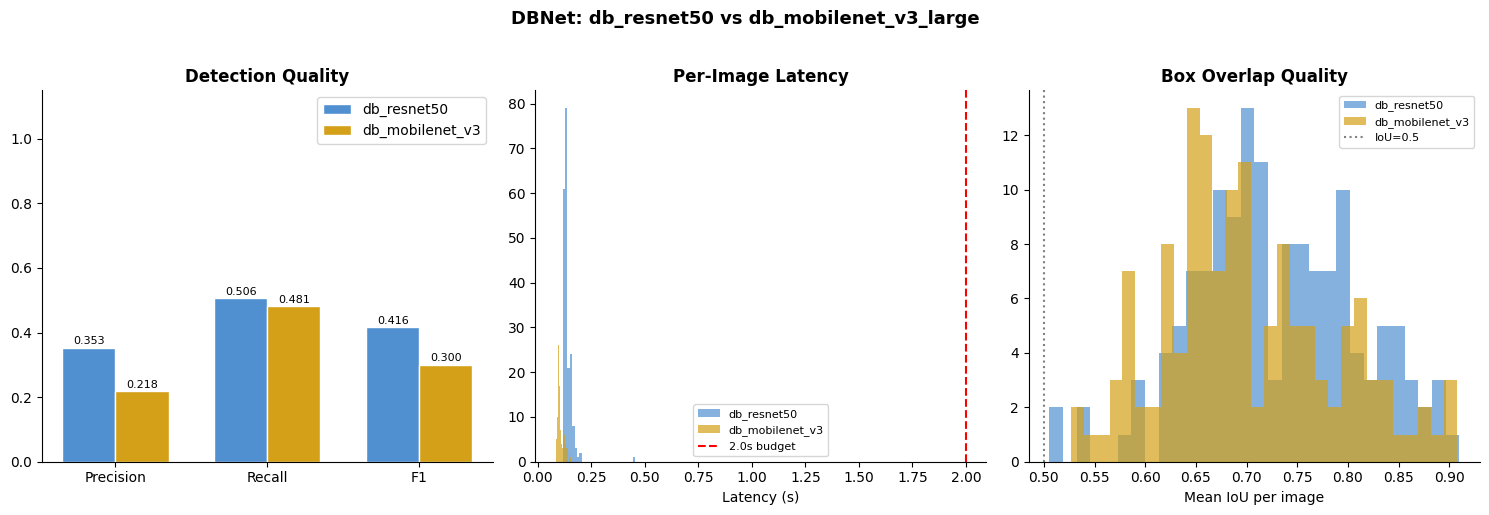

Figure saved ✓


In [16]:
colors = ["#5090d0", "#d4a017"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Quality
ax = axes[0]
mnames = ["Precision","Recall","F1"]
rv = [r50_m["precision"], r50_m["recall"], r50_m["f1"]]
mv = [mob_m["precision"], mob_m["recall"], mob_m["f1"]]
x, bw = np.arange(3), 0.35
ax.bar(x-bw/2, rv, bw, label="db_resnet50",       color=colors[0], edgecolor="white")
ax.bar(x+bw/2, mv, bw, label="db_mobilenet_v3",   color=colors[1], edgecolor="white")
for xi,(r,m) in enumerate(zip(rv,mv)):
    ax.text(xi-bw/2, r+0.01, f"{r:.3f}", ha="center", fontsize=8)
    ax.text(xi+bw/2, m+0.01, f"{m:.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mnames)
ax.set_ylim(0, 1.15)
ax.set_title("Detection Quality", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)

# Latency
ax = axes[1]
ax.hist([r["latency"] for r in r50_results], bins=30, alpha=0.7, label="db_resnet50",     color=colors[0])
ax.hist([r["latency"] for r in mob_results], bins=30, alpha=0.7, label="db_mobilenet_v3", color=colors[1])
ax.axvline(LATENCY_BUDGET, color="red", linestyle="--", lw=1.5, label=f"{LATENCY_BUDGET}s budget")
ax.set_xlabel("Latency (s)")
ax.set_title("Per-Image Latency", fontweight="bold")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

# IoU
ax = axes[2]
ax.hist([r["mean_iou"] for r in r50_results if r["mean_iou"]>0], bins=30, alpha=0.7, label="db_resnet50",     color=colors[0])
ax.hist([r["mean_iou"] for r in mob_results  if r["mean_iou"]>0], bins=30, alpha=0.7, label="db_mobilenet_v3", color=colors[1])
ax.axvline(IOU_THRESHOLD, color="gray", linestyle=":", lw=1.5, label=f"IoU={IOU_THRESHOLD}")
ax.set_xlabel("Mean IoU per image")
ax.set_title("Box Overlap Quality", fontweight="bold")
ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("DBNet: db_resnet50 vs db_mobilenet_v3_large",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02a_detection_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ✓")

## 10. Accuracy vs Latency Tradeoff

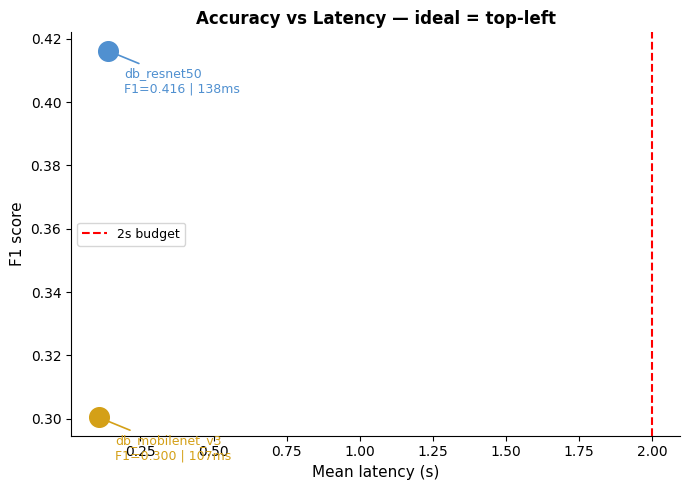

Figure saved ✓


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, m, color in [
    ("db_resnet50",       r50_m, colors[0]),
    ("db_mobilenet_v3",   mob_m, colors[1])
]:
    ax.scatter(m["mean_latency_s"], m["f1"], s=200, color=color, zorder=5)
    ax.annotate(
        f"{name}\nF1={m['f1']:.3f} | {m['mean_latency_s']*1000:.0f}ms",
        xy=(m["mean_latency_s"], m["f1"]),
        xytext=(12, -30), textcoords="offset points",
        fontsize=9, color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1.2)
    )

ax.axvline(LATENCY_BUDGET, color="red", linestyle="--", lw=1.5, label="2s budget")
ax.set_xlabel("Mean latency (s)", fontsize=11)
ax.set_ylabel("F1 score", fontsize=11)
ax.set_title("Accuracy vs Latency — ideal = top-left", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02a_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ✓")

## 11. Visual  Check

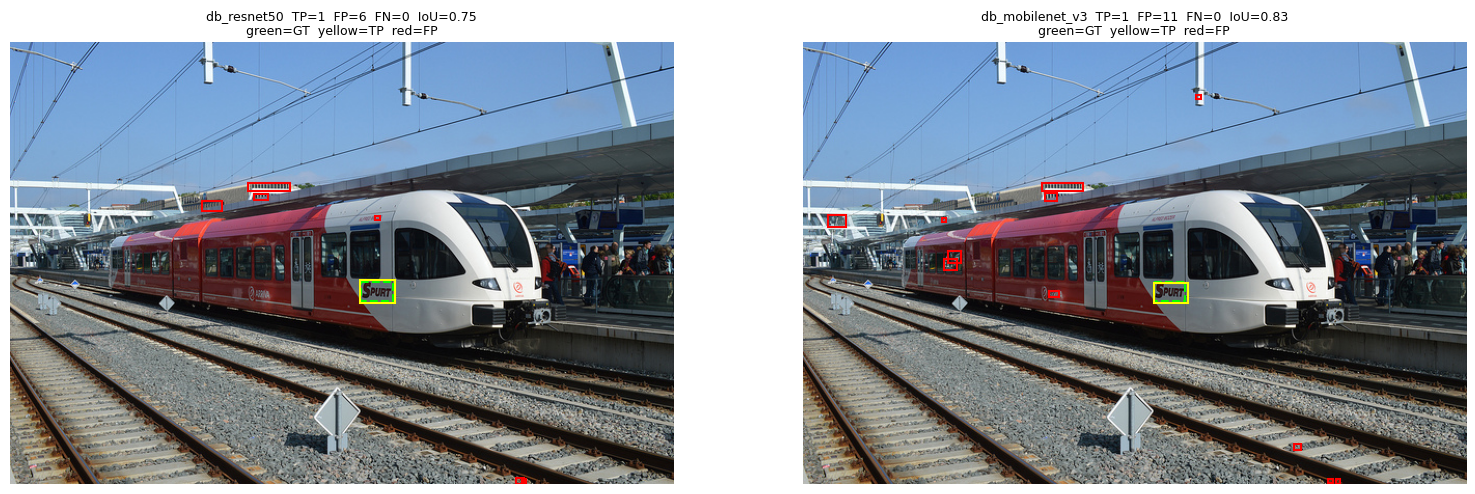

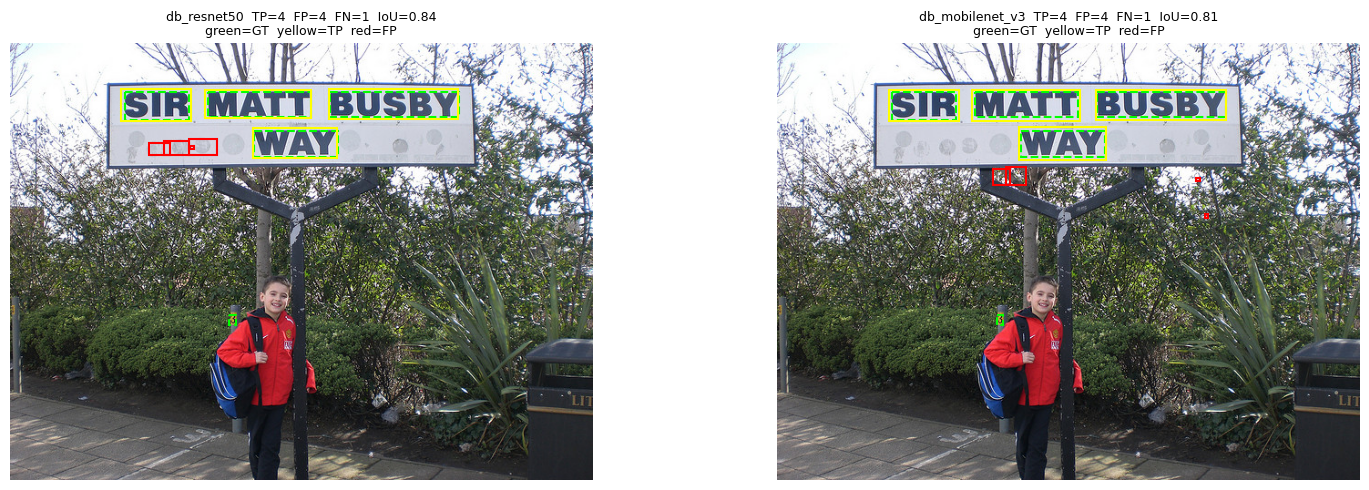

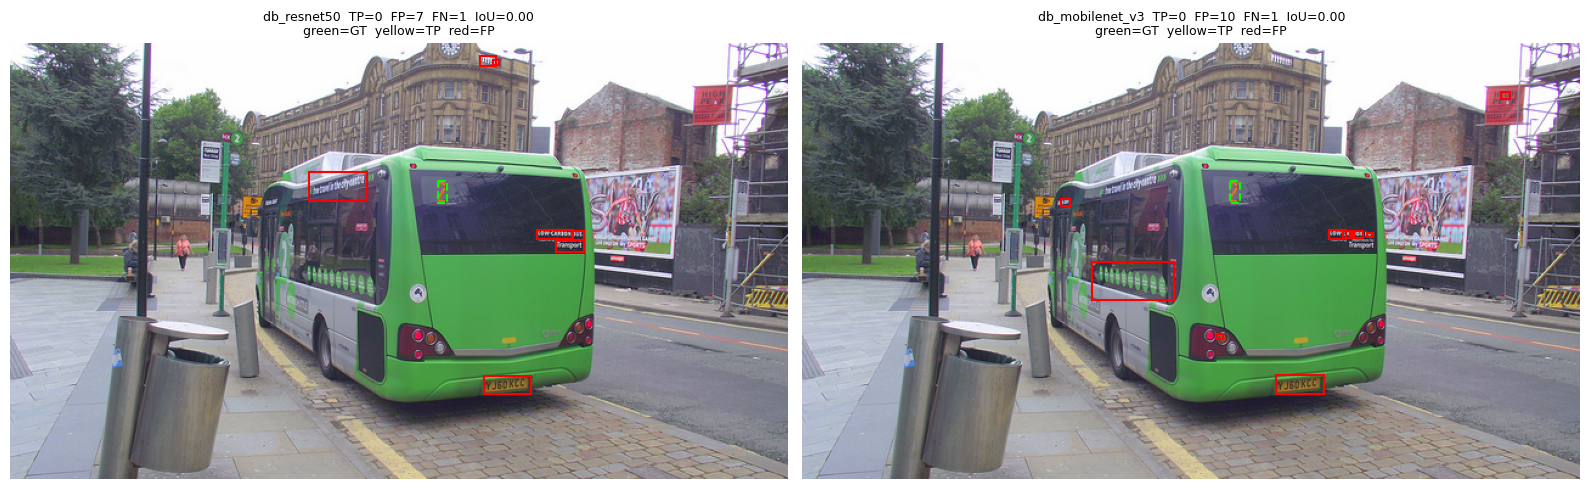

In [18]:
# Side-by-side on 3 random images
# green dashed = GT | yellow = TP | red = FP

for s in random.sample(detection_sample, 3):
    img_path = IMG_DIR / s["file_name"]
    rb, _    = run_doctr_det(model_r50, img_path, s["width"], s["height"])
    mb, _    = run_doctr_det(model_mob, img_path, s["width"], s["height"])
    img_pil  = Image.open(img_path).convert("RGB")
    gt_xyxy  = [xywh_to_xyxy(b) for b in s["gt_boxes"]]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, (name, pred_boxes) in zip(axes, [
        ("db_resnet50", rb), ("db_mobilenet_v3", mb)
    ]):
        ax.imshow(img_pil); ax.axis("off")
        for b in s["gt_boxes"]:
            x, y, w, h = b
            ax.add_patch(patches.Rectangle((x,y), w, h,
                linewidth=1.5, edgecolor="lime",
                facecolor="none", linestyle="--"))
        matched = set()
        for pred in pred_boxes:
            px, py, pw, ph = pred
            pxy = xywh_to_xyxy(pred)
            is_tp = False
            for i, gt in enumerate(gt_xyxy):
                if i not in matched and compute_iou(pxy, gt) >= IOU_THRESHOLD:
                    is_tp = True; matched.add(i); break
            ax.add_patch(patches.Rectangle((px,py), pw, ph,
                linewidth=1.5,
                edgecolor="yellow" if is_tp else "red",
                facecolor="none"))
        tp, fp, fn, iou = match_boxes(pred_boxes, s["gt_boxes"], IOU_THRESHOLD)
        ax.set_title(
            f"{name}  TP={tp}  FP={fp}  FN={fn}  IoU={iou:.2f}\n"
            "green=GT  yellow=TP  red=FP", fontsize=9
        )
    plt.tight_layout(); plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 12. Decision

In [19]:
print("=" * 52)
print("  PHASE 2a — DETECTION MODEL DECISION")
print("=" * 52)

candidates = {}
for name, m in [("db_resnet50", r50_m), ("db_mobilenet_v3_large", mob_m)]:
    within = m["p95_latency_s"] < LATENCY_BUDGET
    print(f"\n  {name}")
    print(f"    F1           : {m['f1']:.4f}")
    print(f"    Recall       : {m['recall']:.4f}")
    print(f"    Mean IoU     : {m['mean_iou']:.4f}")
    print(f"    P95 latency  : {m['p95_latency_s']:.3f}s  "
          f"{'✓ within budget' if within else '✗ EXCEEDS BUDGET'}")
    if within: candidates[name] = m

print()
winner = None
if not candidates:
    print("  ✗ Both models exceed latency budget.")
    print("  → Reduce input resolution before detection.")
elif len(candidates) == 1:
    winner = list(candidates.keys())[0]
    print(f"  ✓ Only one model within budget: {winner}")
else:
    f1_r50 = candidates["db_resnet50"]["f1"]
    f1_mob = candidates["db_mobilenet_v3_large"]["f1"]
    gain   = f1_r50 - f1_mob
    print(f"  F1 gain from db_resnet50: {gain:+.4f}  (threshold={F1_MIN_GAIN})")
    if gain >= F1_MIN_GAIN:
        winner = "db_resnet50"
        print("  ✓ db_resnet50 wins — F1 gain justifies latency cost")
    else:
        winner = "db_mobilenet_v3_large"
        print("  ✓ db_mobilenet_v3_large wins — resnet50 gain too small")
        print("  → Saved latency headroom goes to recognition stage")

det_lat = candidates[winner]["mean_latency_s"] if winner else None

decision = {
    "detection_winner":         winner,
    "detection_mean_latency_s": det_lat,
    "detection_f1":             candidates[winner]["f1"] if winner else None
}
with open(RESULTS_DIR / "02a_decision.json", "w") as f:
    json.dump(decision, f, indent=2)

print(f"\n  Decision saved → outputs/results/02a_decision.json ✓")
print(f"  → Run 02b_recognition_benchmark.ipynb next")

  PHASE 2a — DETECTION MODEL DECISION

  db_resnet50
    F1           : 0.4163
    Recall       : 0.5062
    Mean IoU     : 0.7286
    P95 latency  : 0.169s  ✓ within budget

  db_mobilenet_v3_large
    F1           : 0.3004
    Recall       : 0.4813
    Mean IoU     : 0.7010
    P95 latency  : 0.139s  ✓ within budget

  F1 gain from db_resnet50: +0.1159  (threshold=0.03)
  ✓ db_resnet50 wins — F1 gain justifies latency cost

  Decision saved → outputs/results/02a_decision.json ✓
  → Run 02b_recognition_benchmark.ipynb next


**DETECTION MODEL DECISION**
====================================================
**db_resnet50**

    F1           : 0.4163
    Recall       : 0.5062
    Mean IoU     : 0.7286
    P95 latency  : 0.169s  ✓ within budget

**db_mobilenet_v3_large**

    F1           : 0.3004
    Recall       : 0.4813
    Mean IoU     : 0.7010
    P95 latency  : 0.139s  ✓ within budget

F1 gain from db_resnet50: +0.1159  (threshold=0.03)

**db_resnet50** wins 
F1 gain justifies latency cost.

Decision saved → outputs/results/02a_decision.json ✓